# XGboost Model

In [1]:
# Imports
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [2]:
# Load datasets 
train_df = pd.read_csv("/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/processed/feature_engineered_train_data.csv")
test_df = pd.read_csv("/Users/mateopozoruiz/Projects/Housing-Pricing-End-to-End-ML/data/processed/feature_engineered_test_data.csv")

In [3]:
# Define features and target variable
target = 'price'
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

## Train and Evaluate the model

In [4]:
# Train the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [5]:
# Evaluate the model's performance

y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("XGBoost Performance")
print(f"MAE:{mae:,.2f}")
print(f"RMSE:{rmse:,.2f}")
print(f"R²:{r2:,.4f}")

XGBoost Performance
MAE:32,708.78
RMSE:72,815.63
R²:0.9590


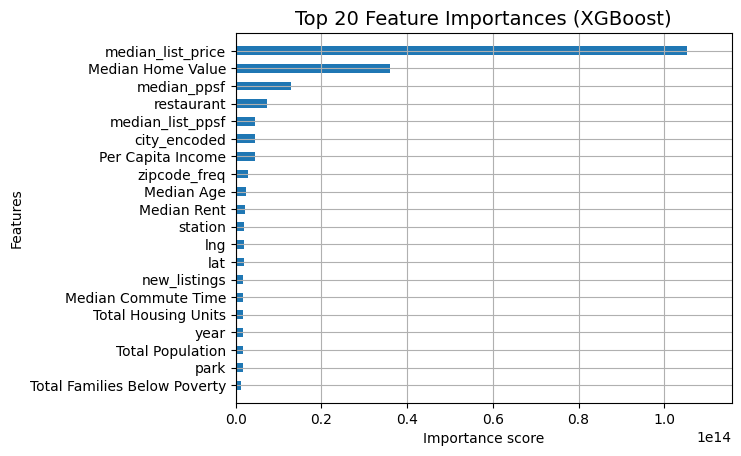

In [6]:
# Plot importances
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(
    xgb_model,
    importance_type="gain",
    max_num_features=20,
    height=0.5,
    show_values=False
)
plt.title("Top 20 Feature Importances (XGBoost)", fontsize=14)
plt.show()